In [1]:
# !pip install opencv-python

In [106]:
import cv2 as cv
import numpy as np
import os
import mediapipe as mp

In [107]:
!python --version

Python 3.9.5


In [108]:
# view all vide samples..
data_path = 'SIGN_LANGUAGE'
datasets = os.listdir(path=data_path)
print(datasets[:])

['20.MOV', 'A.MOV', 'Abdominal.MOV', 'After.MOV', 'Ago.MOV', 'Alcohol.MOV', 'All.MOV', 'Alternating.MOV', 'Always.MOV', 'Am.MOV', 'And.MOV', 'Any.MOV', 'Anything.MOV', 'Are.MOV', 'Around.MOV', 'at.MOV', 'Back.MOV', 'Be.MOV', 'Body.MOV', 'Bring.MOV', 'Brought.MOV', 'Brown.MOV', 'Bushes.MOV', 'But.MOV', 'Buy.MOV', 'Can.MOV', 'Catarrh.MOV', 'Cause.MOV', 'Coloured.MOV', 'Comes.MOV', 'Complaint.MOV', 'Constipation.MOV', 'Cough.MOV', 'Coughing.MOV', 'Counter.MOV', 'Current.MOV', 'Dark.MOV', 'Day.MOV', 'Days.MOV', 'Describe.MOV', 'Diarrhea.MOV', 'Does.MOV', 'Done.MOV', 'Eat.MOV', 'Education.MOV', 'Eye.MOV', 'Fever.MOV', 'Food.MOV', 'For.MOV', 'From.MOV', 'Go.MOV', 'Have.MOV', 'Having.MOV', 'Headache.MOV', 'Herbal concoction.MOV', 'Home.MOV', 'Hospital.MOV', 'Hot.MOV', 'House.MOV', 'How.MOV', 'Hungry.MOV', 'I.MOV', 'Ilorin.MOV', 'IMG_2248.MOV', 'Immediately.MOV', 'In.MOV', 'Is.MOV', 'It.MOV', 'Late _ Delay.MOV', 'Let.MOV', 'Level.MOV', 'Likely_thesame.MOV', 'Long.MOV', 'Love.MOV', 'Makes.MOV',

In [109]:
datasets[-1]

'_.MOV'

In [110]:

for vid_name in datasets: 
    old_name = f'{data_path}/{vid_name}'
    new_name = vid_name.split('.')[0].strip()
    print(new_name)
    os.rename(old_name, f'{data_path}/{new_name}.MOV')

print('All video name are stripped... !!!!')

20
A
Abdominal
After
Ago
Alcohol
All
Alternating
Always
Am
And
Any
Anything
Are
Around
at
Back
Be
Body
Bring
Brought
Brown
Bushes
But
Buy
Can
Catarrh
Cause
Coloured
Comes
Complaint
Constipation
Cough
Coughing
Counter
Current
Dark
Day
Days
Describe
Diarrhea
Does
Done
Eat
Education
Eye
Fever
Food
For
From
Go
Have
Having
Headache
Herbal concoction
Home
Hospital
Hot
House
How
Hungry
I
Ilorin
IMG_2248
Immediately
In
Is
It
Late _ Delay
Let
Level
Likely_thesame
Long
Love
Makes
Me
Medicine
Month
Morning
Mosquito
Most
My
Need
Night
No
Normally
Not
Notice
Occupation
Of
Off
Ok
Old
On
Once
One day
One
Or
Other
Over
Pains
Paracetamol
Part
Passage
Patient
Pepper_spicy
Peptic
Poor
Positive
Present
Prolonged
Rash
Received
Recurrent _Often
Reduce
Result
See
Since
Sleeping
Smoke
Stomach
Store_vendor
Student
Sure
Take
Test
Testing
The
There
These
This
Time
To
Treatment
Two
Ulcer
Under
Undergraduate
Urine
Used
Vomiting
Water
Weeks
Well
What
When
Where
Which
Will
With
Years
Yellow was
Yes
You
Your
_
All vi

In [111]:
print('Initial Video Data Size: ', len(datasets))

Initial Video Data Size:  156


In [112]:
# load actiual vid
vid = cv.VideoCapture(f'{data_path}/{datasets[1]}')
if not vid.isOpened():
    print('no vidoe sources')
    exit()
vid

< cv2.VideoCapture 0000023F43EFD550>

In [113]:
# read the acutal video
frame_count = 0
while True: 
    rec, frame = vid.read()
    
    
    if not rec: 
        break

    frame = cv.resize(frame, (224,224))
    cv.imshow(f'Sign for {datasets[1]}', frame)
    frame_count = frame_count + 1
    print(f'Frame Count {frame_count}')

    if cv.waitKey(1) & 0xFF == ord('q'):
        break

vid.release()
cv.destroyAllWindows()
print(f'Total Frame count: {frame_count}')

Frame Count 1
Frame Count 2
Frame Count 3
Frame Count 4
Frame Count 5
Frame Count 6
Frame Count 7
Frame Count 8
Frame Count 9
Frame Count 10
Frame Count 11
Frame Count 12
Frame Count 13
Frame Count 14
Frame Count 15
Frame Count 16
Frame Count 17
Frame Count 18
Frame Count 19
Frame Count 20
Frame Count 21
Frame Count 22
Frame Count 23
Frame Count 24
Frame Count 25
Frame Count 26
Frame Count 27
Frame Count 28
Frame Count 29
Frame Count 30
Frame Count 31
Frame Count 32
Frame Count 33
Frame Count 34
Frame Count 35
Frame Count 36
Frame Count 37
Frame Count 38
Frame Count 39
Frame Count 40
Frame Count 41
Frame Count 42
Frame Count 43
Frame Count 44
Frame Count 45
Frame Count 46
Frame Count 47
Frame Count 48
Frame Count 49
Frame Count 50
Frame Count 51
Frame Count 52
Frame Count 53
Frame Count 54
Frame Count 55
Frame Count 56
Frame Count 57
Frame Count 58
Frame Count 59
Frame Count 60
Frame Count 61
Frame Count 62
Frame Count 63
Frame Count 64
Frame Count 65
Frame Count 66
Frame Count 67
Fram

In [16]:
# loading entire video by creating a helper function

def extract_frames(video_path, vid_name, max_frames=200, output_path = 'FRAMES/'):  
    full_path = f'{video_path}/{vid_name}'
    output_folder = f"{output_path}{vid_name.split('.')[0]}"

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    cap = cv.VideoCapture(full_path)
    count = 0
    last_frame = None

    # Read and save actual frames
    while cap.isOpened() and count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv.resize(frame, (224, 224))
        frame_path = os.path.join(output_folder, f"frame_{count}.jpg")
        cv.imwrite(frame_path, frame)

        last_frame = frame.copy()
        count += 1

    # Pad with last frame if total frames < 200
    while count < max_frames:
        blank = 128 * np.ones((224, 224, 3), dtype=np.uint8)  # gray image
        frame_path = os.path.join(output_folder, f"frame_{count}.jpg")
        cv.imwrite(frame_path, blank)
        count += 1

    cap.release()
    vid.release()

In [18]:
# load single sample of image
frame_size = 100
for clip in datasets:       
    extract_frames('SIGN_LANGUAGE', clip , max_frames=frame_size)
    comment = f'''===========================================
    frame extraction for {clip} Completed.. Total Frame:{frame_size}
    ========================================================'''
    print(comment)

print(f'frame extraction complete for All:  {len(datasets)} video')


    frame extraction for 20.MOV Completed.. Total Frame:100
    frame extraction for A.MOV Completed.. Total Frame:100
    frame extraction for Abdominal.MOV Completed.. Total Frame:100
    frame extraction for After.MOV Completed.. Total Frame:100
    frame extraction for Ago.MOV Completed.. Total Frame:100
    frame extraction for Alcohol.MOV Completed.. Total Frame:100
    frame extraction for All.MOV Completed.. Total Frame:100
    frame extraction for Alternating.MOV Completed.. Total Frame:100
    frame extraction for Always.MOV Completed.. Total Frame:100
    frame extraction for Am.MOV Completed.. Total Frame:100
    frame extraction for And.MOV Completed.. Total Frame:100
    frame extraction for Any.MOV Completed.. Total Frame:100
    frame extraction for Anything.MOV Completed.. Total Frame:100
    frame extraction for Are.MOV Completed.. Total Frame:100
    frame extraction for Around.MOV Completed.. Total Frame:100
    frame extraction for at.MOV Completed.. Total Frame:10

In [15]:
# extract_frames('SIGN_LANGUAGE', 'Which.MOV' , max_frames=200)
# comment = f'''===========================================
# frame extraction for Which Completed.. Total Frame:200
# ========================================================'''
# print(comment)

### Landmark Extraction from video frames..

In [14]:
# !pip install mediapipe

In [19]:
import cv2
import mediapipe as mp
import numpy as np
import os

mp_holistic = mp.solutions.holistic

def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    
    return np.concatenate([pose, lh, rh])

In [20]:
import cv2
import mediapipe as mp
import numpy as np

# helper method to extact landmark from the image
def extract_mediapipe_features(image, holistic_model):
    # Convert to RGB for MediaPipe
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = holistic_model.process(img_rgb)

    # Extract Pose (33 landmarks * 4 values: x, y, z, visibility)
    if results.pose_landmarks:
        pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten()
    else:
        pose = np.zeros(33 * 4)

    # Extract Left Hand (21 landmarks * 3 values: x, y, z)
    if results.left_hand_landmarks:
        lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten()
    else:
        lh = np.zeros(21 * 3)

    # Extract Right Hand (21 landmarks * 3 values: x, y, z)
    if results.right_hand_landmarks:
        rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten()
    else:
        rh = np.zeros(21 * 3)

    # merge all into a single numpy array
    return np.concatenate([pose, lh, rh])

# let use extract the landmark feature.. 
def generate_features(image_path):
    mp_holistic = mp.solutions.holistic
    
    # Use 'with' to ensure the model closes properly
    with mp_holistic.Holistic(static_image_mode=True) as holistic:
        image = cv2.imread(image_path)
        if image is None:
            return None
        
        # Get the single numeric array
        feature_vector = extract_mediapipe_features(image, holistic)
        return feature_vector

# Example usage:
# result = generate_features("my_photo.jpg")
# print(result.shape)  # Should be (258,) representing all concatenated values


In [40]:
class_list = [cls.split('.')[0].lower() for cls in datasets]
folder_name = [cls.split('.')[0] for cls in datasets]

class_list[:5]

['20', 'a', 'abdominal', 'after', 'ago']

In [28]:
from pathlib import Path

frame_path = Path('FRAMES')
frame_path

WindowsPath('FRAMES')

In [35]:
all_path = list(frame_path.glob('*/*.jpg'))
all_path = [str(p) for p in all_path]
all_path[:5]

['FRAMES\\20\\frame_0.jpg',
 'FRAMES\\20\\frame_1.jpg',
 'FRAMES\\20\\frame_10.jpg',
 'FRAMES\\20\\frame_11.jpg',
 'FRAMES\\20\\frame_12.jpg']

In [142]:
int(all_path[0].split('_')[1].split('.')[0])

0

In [135]:
# sorted(os.listdir('FRAMES/A/'))

In [32]:
print('Total Image Size : ', len(all_path))

Total Image Size :  15600


In [36]:
generate_features(all_path[0])

array([ 3.37649621e-02,  1.25512600e-01, -3.38375956e-01,  9.51559305e-01,
        4.75528166e-02,  8.75495076e-02, -2.75685042e-01,  9.41390038e-01,
        5.53962179e-02,  8.76250267e-02, -2.76315659e-01,  9.41816092e-01,
        6.29336536e-02,  8.77964497e-02, -2.76944816e-01,  9.53179181e-01,
        1.54049741e-02,  8.21280479e-02, -3.60490948e-01,  9.28788602e-01,
        1.24297081e-03,  8.08450580e-02, -3.60448539e-01,  9.16268051e-01,
       -1.31682055e-02,  7.85433650e-02, -3.60703737e-01,  9.15101469e-01,
        4.70414683e-02,  8.77104998e-02,  4.94011305e-02,  9.44336593e-01,
       -5.27009368e-02,  7.46595263e-02, -3.35610390e-01,  9.26138103e-01,
        4.38884422e-02,  1.57335401e-01, -2.06006050e-01,  9.57405388e-01,
        4.37093712e-03,  1.54116705e-01, -3.17406148e-01,  9.38910663e-01,
       -1.75145343e-02,  2.39885211e-01,  3.20962399e-01,  9.95501220e-01,
       -2.15552449e-01,  2.13956758e-01, -4.90634590e-01,  9.86953259e-01,
        1.49178192e-01,  

In [155]:
# let us collect the frame image and the label, before collecting features.... 
frame_data_paths = {}
label_data = {}

for index in range (len(folder_name)): 
    f_name = folder_name[index]
    temp_path = list(frame_path.glob(f'{f_name}/*.jpg'))
    frame_data_paths[f_name] = [str(p) for p in temp_path]
    label_data[f_name] = index

print('Collection Complete')

Collection Complete


In [156]:
frame_data_paths.keys()

dict_keys(['20', 'A', 'Abdominal', 'After', 'Ago', 'Alcohol', 'All', 'Alternating', 'Always', 'Am', 'And', 'Any', 'Anything', 'Are', 'Around', 'at', 'Back', 'Be', 'Body', 'Bring', 'Brought', 'Brown', 'Bushes', 'But', 'Buy', 'Can', 'Catarrh', 'Cause', 'Coloured', 'Comes', 'Complaint', 'Constipation', 'Cough', 'Coughing', 'Counter', 'Current', 'Dark', 'Day', 'Days', 'Describe', 'Diarrhea', 'Does', 'Done', 'Eat', 'Education', 'Eye', 'Fever', 'Food', 'For', 'From', 'Go', 'Have', 'Having', 'Headache', 'Herbal concoction', 'Home', 'Hospital', 'Hot', 'House', 'How', 'Hungry', 'I', 'Ilorin', 'IMG_2248', 'Immediately', 'In', 'Is', 'It', 'Late _ Delay', 'Let', 'Level', 'Likely_thesame', 'Long', 'Love', 'Makes', 'Me', 'Medicine', 'Month', 'Morning', 'Mosquito', 'Most', 'My', 'Need', 'Night', 'No', 'Normally', 'Not', 'Notice', 'Occupation', 'Of', 'Off', 'Ok', 'Old', 'On', 'Once', 'One day', 'One', 'Or', 'Other', 'Over', 'Pains', 'Paracetamol', 'Part', 'Passage', 'Patient', 'Pepper_spicy', 'Peptic'

In [157]:
plot_data = {}
for key, val in frame_data_paths.items(): 
    print(f'{key}: {len(val)}')
    plot_data[key] = len(val)

20: 100
A: 100
Abdominal: 100
After: 100
Ago: 100
Alcohol: 100
All: 100
Alternating: 100
Always: 100
Am: 100
And: 100
Any: 100
Anything: 100
Are: 100
Around: 100
at: 100
Back: 100
Be: 100
Body: 100
Bring: 100
Brought: 100
Brown: 100
Bushes: 100
But: 100
Buy: 100
Can: 100
Catarrh: 100
Cause: 100
Coloured: 100
Comes: 100
Complaint: 100
Constipation: 100
Cough: 100
Coughing: 100
Counter: 100
Current: 100
Dark: 100
Day: 100
Days: 100
Describe: 100
Diarrhea: 100
Does: 100
Done: 100
Eat: 100
Education: 100
Eye: 100
Fever: 100
Food: 100
For: 100
From: 100
Go: 100
Have: 100
Having: 100
Headache: 100
Herbal concoction: 100
Home: 100
Hospital: 100
Hot: 100
House: 100
How: 100
Hungry: 100
I: 100
Ilorin: 100
IMG_2248: 100
Immediately: 100
In: 100
Is: 100
It: 100
Late _ Delay: 100
Let: 100
Level: 100
Likely_thesame: 100
Long: 100
Love: 100
Makes: 100
Me: 100
Medicine: 100
Month: 100
Morning: 100
Mosquito: 100
Most: 100
My: 100
Need: 100
Night: 100
No: 100
Normally: 100
Not: 100
Notice: 100
Occupati

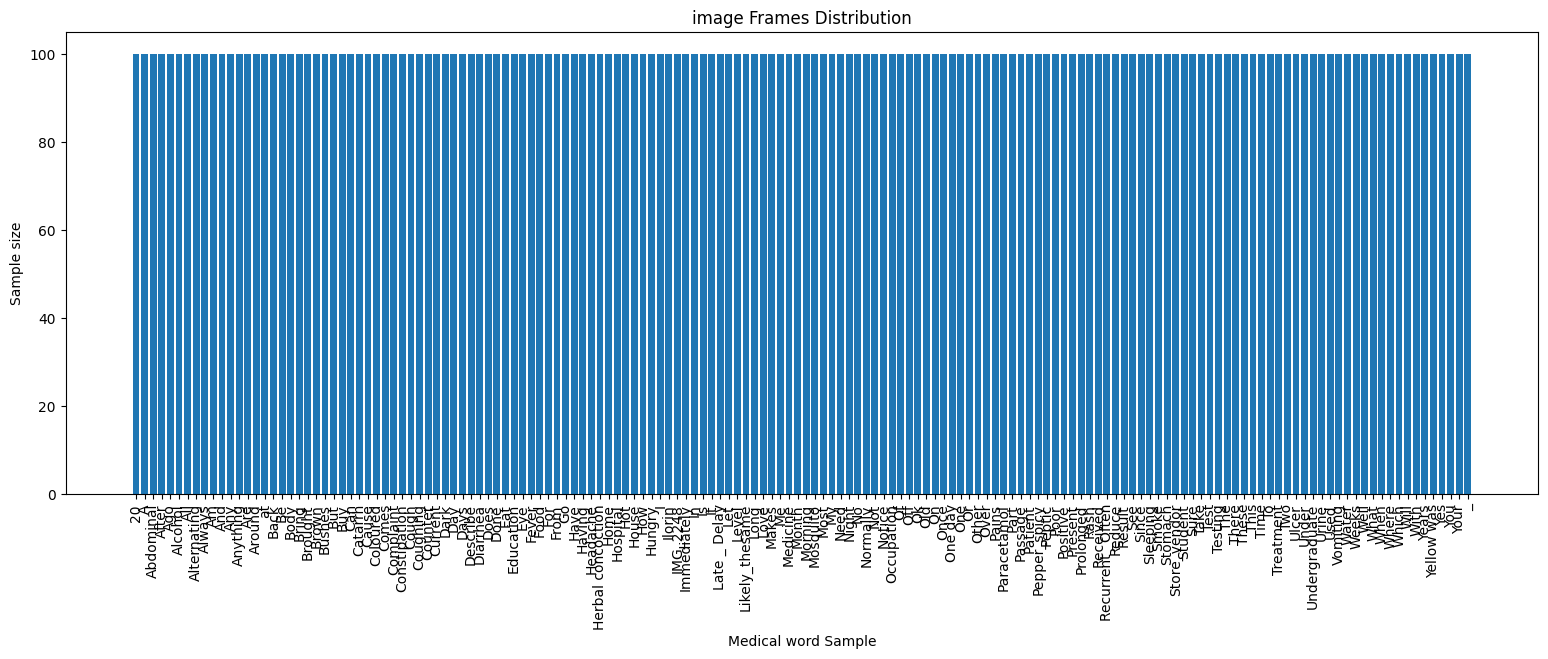

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=(19,6))
plt.title('image Frames Distribution')
plt.bar(plot_data.keys(), plot_data.values())
plt.xticks(rotation=90)
plt.xlabel('Medical word Sample')
plt.ylabel('Sample size')
plt.show()

In [176]:
def custom_sorting(frames):
    sorted_list = sorted(frames, key= lambda x: int(x.split('_')[-1].split('.')[0]))
    return sorted_list

custom_sorting(frame_data_paths['_'])[:5]

['FRAMES\\_\\frame_0.jpg',
 'FRAMES\\_\\frame_1.jpg',
 'FRAMES\\_\\frame_2.jpg',
 'FRAMES\\_\\frame_3.jpg',
 'FRAMES\\_\\frame_4.jpg']

In [173]:
# sorted(frame_data_paths['_'], key= lambda x: int(x.split('_')[-1].split('.')[0]))

In [169]:
frame_data_paths['_'][0].split('_')

['FRAMES\\', '\\frame', '0.jpg']

In [78]:
label_data.values()

dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155])

In [83]:
folder_name[:5]

['20', 'A', 'Abdominal', 'After', 'Ago']

In [181]:
# custom_sorting(frame_data_paths['Ago'])

In [178]:
# sample img features
X = []
for folder in folder_name[:5]:
    frames = []
    samples_f = custom_sorting(frame_data_paths[folder][1:24])
    print('='*100)
    print(samples_f)
    for sample in samples_f: 
        key_points = generate_features(sample)
        # append each feature for each key frame
        frames.append(key_points)
        
    # append all time stamp feature
    X.append(frames)

['FRAMES\\20\\frame_1.jpg', 'FRAMES\\20\\frame_2.jpg', 'FRAMES\\20\\frame_3.jpg', 'FRAMES\\20\\frame_10.jpg', 'FRAMES\\20\\frame_11.jpg', 'FRAMES\\20\\frame_12.jpg', 'FRAMES\\20\\frame_13.jpg', 'FRAMES\\20\\frame_14.jpg', 'FRAMES\\20\\frame_15.jpg', 'FRAMES\\20\\frame_16.jpg', 'FRAMES\\20\\frame_17.jpg', 'FRAMES\\20\\frame_18.jpg', 'FRAMES\\20\\frame_19.jpg', 'FRAMES\\20\\frame_20.jpg', 'FRAMES\\20\\frame_21.jpg', 'FRAMES\\20\\frame_22.jpg', 'FRAMES\\20\\frame_23.jpg', 'FRAMES\\20\\frame_24.jpg', 'FRAMES\\20\\frame_25.jpg', 'FRAMES\\20\\frame_26.jpg', 'FRAMES\\20\\frame_27.jpg', 'FRAMES\\20\\frame_28.jpg', 'FRAMES\\20\\frame_29.jpg']
['FRAMES\\A\\frame_1.jpg', 'FRAMES\\A\\frame_2.jpg', 'FRAMES\\A\\frame_3.jpg', 'FRAMES\\A\\frame_10.jpg', 'FRAMES\\A\\frame_11.jpg', 'FRAMES\\A\\frame_12.jpg', 'FRAMES\\A\\frame_13.jpg', 'FRAMES\\A\\frame_14.jpg', 'FRAMES\\A\\frame_15.jpg', 'FRAMES\\A\\frame_16.jpg', 'FRAMES\\A\\frame_17.jpg', 'FRAMES\\A\\frame_18.jpg', 'FRAMES\\A\\frame_19.jpg', 'FRAMES\\

In [182]:
# test run .. 
print('Test run 5 sample with just only 4 frame and each frames comes with 258 features.. ')
X = np.array(X)
X.shape

Test run 5 sample with just only 4 frame and each frames comes with 258 features.. 


(5, 23, 258)

In [184]:
# observation
# 1. observed that the image does not follow proper sequence 
# 2. a refactor of the frame numbering is needed... 
# =================================================
# let us monitor 10, 10 samples.. 

In [187]:
# full img features
X = []
for folder in folder_name:
    frames = []
    samples_f = custom_sorting(frame_data_paths[folder])
    print('='*100)
    print(f'Extraction for frame folder: {folder} started.....')
    print(samples_f[:5])
    for sample in samples_f: 
        key_points = generate_features(sample)
        # append each feature for each key frame
        frames.append(key_points)
    print(f'Extraction for frame folder: {folder} Completed..... ')
        
    # append all time stamp feature
    X.append(frames)

Extraction for frame folder: 20 started.....
['FRAMES\\20\\frame_0.jpg', 'FRAMES\\20\\frame_1.jpg', 'FRAMES\\20\\frame_2.jpg', 'FRAMES\\20\\frame_3.jpg', 'FRAMES\\20\\frame_4.jpg']
Extraction for frame folder: 20 Completed..... 
Extraction for frame folder: A started.....
['FRAMES\\A\\frame_0.jpg', 'FRAMES\\A\\frame_1.jpg', 'FRAMES\\A\\frame_2.jpg', 'FRAMES\\A\\frame_3.jpg', 'FRAMES\\A\\frame_4.jpg']
Extraction for frame folder: A Completed..... 
Extraction for frame folder: Abdominal started.....
['FRAMES\\Abdominal\\frame_0.jpg', 'FRAMES\\Abdominal\\frame_1.jpg', 'FRAMES\\Abdominal\\frame_2.jpg', 'FRAMES\\Abdominal\\frame_3.jpg', 'FRAMES\\Abdominal\\frame_4.jpg']
Extraction for frame folder: Abdominal Completed..... 
Extraction for frame folder: After started.....
['FRAMES\\After\\frame_0.jpg', 'FRAMES\\After\\frame_1.jpg', 'FRAMES\\After\\frame_2.jpg', 'FRAMES\\After\\frame_3.jpg', 'FRAMES\\After\\frame_4.jpg']
Extraction for frame folder: After Completed..... 
Extraction for frame 

In [188]:
X = np.array(X)
X.shape

(156, 100, 258)

In [190]:
X[0].shape

(100, 258)

In [191]:
np.save('x_10_feature.npy', X)
print('Print Successfully.....')

Print Successfully.....


In [194]:
y  = np.array(range(len(folder_name)))
y[:5]

array([0, 1, 2, 3, 4])

##### Keyframe Visualization

In [202]:
from PIL import Image
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

In [221]:


mp_drawing = mp.solutions.drawing_utils
mp_holistic = mp.solutions.holistic

def plot_key_frame_from_array(image_bgr, ax=None):
    """
    image_bgr: numpy array in BGR format (from cv2.imread / cap.read())
    ax: optional matplotlib axis to plot on
    """
    # Convert BGR to RGB for MediaPipe
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # Run holistic model
    with mp_holistic.Holistic(static_image_mode=True) as holistic:
        results = holistic.process(img_rgb)

        # Draw landmarks on the image
        mp_drawing.draw_landmarks(
            image=img_rgb,
            landmark_list=results.pose_landmarks,
            connections=mp_holistic.POSE_CONNECTIONS,
        )
        mp_drawing.draw_landmarks(
            image=img_rgb,
            landmark_list=results.left_hand_landmarks,
            connections=mp_holistic.HAND_CONNECTIONS,
        )
        mp_drawing.draw_landmarks(
            image=img_rgb,
            landmark_list=results.right_hand_landmarks,
            connections=mp_holistic.HAND_CONNECTIONS,
        )

    # Plot
    if ax is None:
        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb)
        plt.title("Key Frame with Landmarks")
        plt.axis("off")
        plt.show()
    else:
        ax.imshow(img_rgb)
        ax.set_title("Key Frame")
        ax.axis("off")

In [204]:
# numpy image
sample_path = frame_data_paths['A'][0]
img = cv2.imread(sample_path)
img

array([[[164, 192, 203],
        [161, 189, 200],
        [163, 191, 202],
        ...,
        [222, 221, 225],
        [223, 222, 226],
        [223, 222, 226]],

       [[162, 190, 201],
        [160, 188, 199],
        [163, 191, 202],
        ...,
        [222, 221, 225],
        [223, 222, 226],
        [223, 222, 226]],

       [[159, 189, 200],
        [158, 188, 199],
        [164, 192, 203],
        ...,
        [222, 221, 225],
        [223, 222, 226],
        [223, 222, 226]],

       ...,

       [[ 41,  17,  19],
        [ 38,  17,  16],
        [ 37,  13,  15],
        ...,
        [ 93,  63,  52],
        [107,  69,  57],
        [116,  74,  61]],

       [[ 41,  15,  15],
        [ 39,  16,  14],
        [ 42,  16,  16],
        ...,
        [ 97,  64,  55],
        [105,  69,  59],
        [113,  73,  61]],

       [[ 40,  15,  13],
        [ 38,  13,  11],
        [ 42,  17,  15],
        ...,
        [ 97,  64,  55],
        [106,  69,  61],
        [114,  75,  66]]

In [205]:
img.shape

(224, 224, 3)

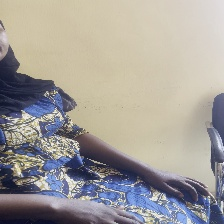

In [201]:
# quick visual...
Image.open(frame_data_paths['A'][0])

In [206]:
frame_data_paths.keys()

dict_keys(['20', 'A', 'Abdominal', 'After', 'Ago', 'Alcohol', 'All', 'Alternating', 'Always', 'Am', 'And', 'Any', 'Anything', 'Are', 'Around', 'at', 'Back', 'Be', 'Body', 'Bring', 'Brought', 'Brown', 'Bushes', 'But', 'Buy', 'Can', 'Catarrh', 'Cause', 'Coloured', 'Comes', 'Complaint', 'Constipation', 'Cough', 'Coughing', 'Counter', 'Current', 'Dark', 'Day', 'Days', 'Describe', 'Diarrhea', 'Does', 'Done', 'Eat', 'Education', 'Eye', 'Fever', 'Food', 'For', 'From', 'Go', 'Have', 'Having', 'Headache', 'Herbal concoction', 'Home', 'Hospital', 'Hot', 'House', 'How', 'Hungry', 'I', 'Ilorin', 'IMG_2248', 'Immediately', 'In', 'Is', 'It', 'Late _ Delay', 'Let', 'Level', 'Likely_thesame', 'Long', 'Love', 'Makes', 'Me', 'Medicine', 'Month', 'Morning', 'Mosquito', 'Most', 'My', 'Need', 'Night', 'No', 'Normally', 'Not', 'Notice', 'Occupation', 'Of', 'Off', 'Ok', 'Old', 'On', 'Once', 'One day', 'One', 'Or', 'Other', 'Over', 'Pains', 'Paracetamol', 'Part', 'Passage', 'Patient', 'Pepper_spicy', 'Peptic'

In [209]:
about_frames_path = frame_data_paths['Around'][:8]
about_frames_path

['FRAMES\\Around\\frame_0.jpg',
 'FRAMES\\Around\\frame_1.jpg',
 'FRAMES\\Around\\frame_10.jpg',
 'FRAMES\\Around\\frame_11.jpg',
 'FRAMES\\Around\\frame_12.jpg',
 'FRAMES\\Around\\frame_13.jpg',
 'FRAMES\\Around\\frame_14.jpg',
 'FRAMES\\Around\\frame_15.jpg']

In [215]:
def get_numpy_samples(frames_numpy):
    plot_image = []
    for path in frames_numpy: 
        print(path)
        plot_image.append(cv2.imread(path))
    
    return np.array(plot_image)

In [220]:
images = get_numpy_samples(about_frames_path)
images.shape

FRAMES\Around\frame_0.jpg
FRAMES\Around\frame_1.jpg
FRAMES\Around\frame_10.jpg
FRAMES\Around\frame_11.jpg
FRAMES\Around\frame_12.jpg
FRAMES\Around\frame_13.jpg
FRAMES\Around\frame_14.jpg
FRAMES\Around\frame_15.jpg


(8, 224, 224, 3)

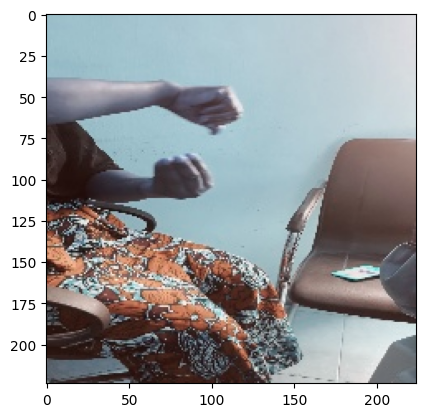

In [224]:
plt.imshow(images[0])

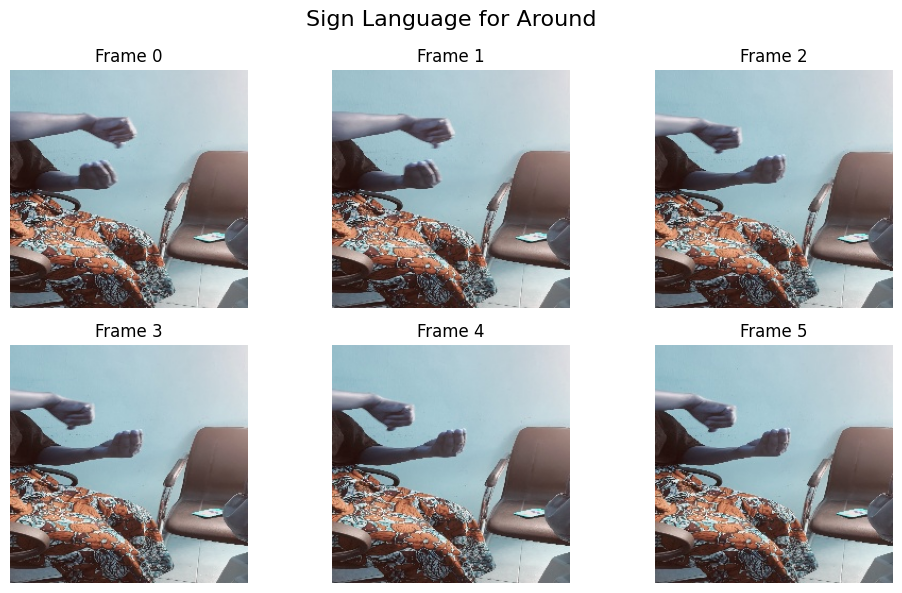

In [240]:
import matplotlib.pyplot as plt
import cv2

def plot_images(images, title='Around'): 
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    
    for i, ax in enumerate(axes.flat):
        # img = cv2.imread(images[i])
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = images[i]    
        ax.imshow(img)
        ax.set_title(f"Frame {i}")
        ax.axis("off")
    
    fig.suptitle(f'Sign Language for {title}', fontsize=16)
    plt.tight_layout()
    plt.show()


plot_images(images)

FRAMES\Any\frame_0.jpg
FRAMES\Any\frame_1.jpg
FRAMES\Any\frame_10.jpg
FRAMES\Any\frame_11.jpg
FRAMES\Any\frame_12.jpg
FRAMES\Any\frame_13.jpg
FRAMES\Any\frame_14.jpg
FRAMES\Any\frame_15.jpg


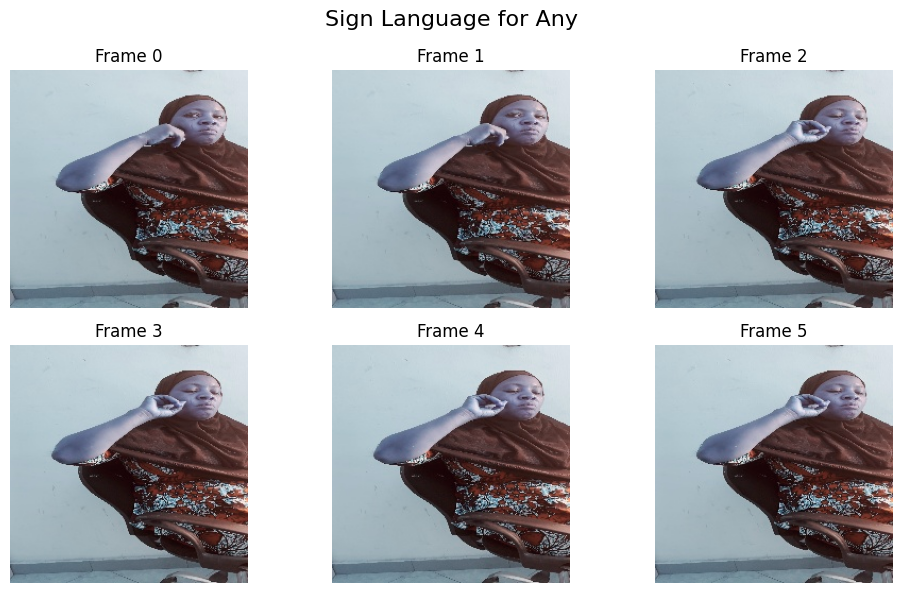

In [242]:
any_frames_path = frame_data_paths['Any'][:8]
images = get_numpy_samples(any_frames_path)
plot_images(images, 'Any')

FRAMES\Can\frame_0.jpg
FRAMES\Can\frame_1.jpg
FRAMES\Can\frame_10.jpg
FRAMES\Can\frame_11.jpg
FRAMES\Can\frame_12.jpg
FRAMES\Can\frame_13.jpg
FRAMES\Can\frame_14.jpg
FRAMES\Can\frame_15.jpg


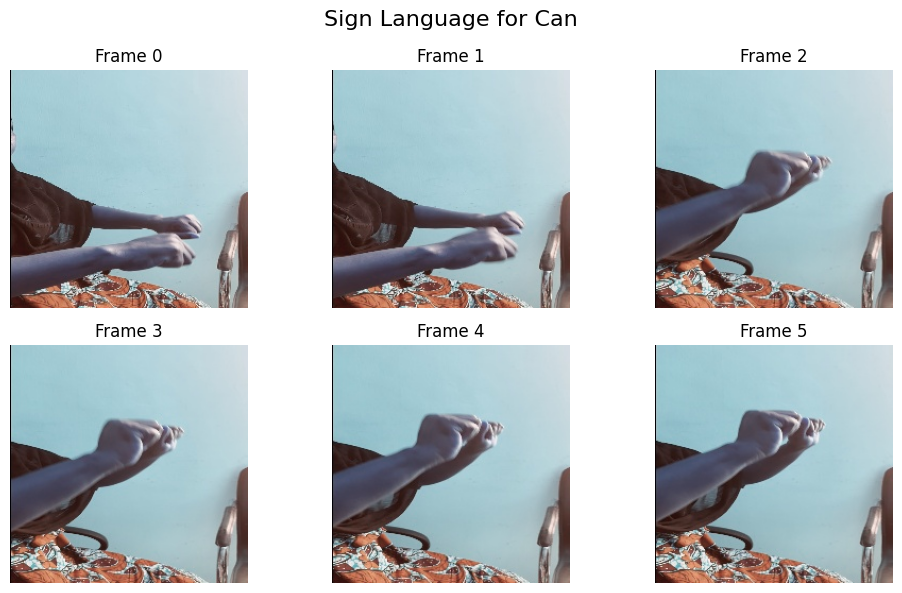

In [243]:
any_frames_path = frame_data_paths['Can'][:8]
images = get_numpy_samples(any_frames_path)
plot_images(images, 'Can')